In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load datasets

trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

In [4]:
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [5]:
print("Trades columns:")
print(trades.columns)

print("\nSentiment columns:")
print(sentiment.columns)

Trades columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

Sentiment columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [6]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
# Convert trader timestamp to datetime
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

# Create date-only column
trades["date"] = trades["Timestamp IST"].dt.date

# Convert sentiment date column
sentiment["date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

In [9]:
print(trades[["Timestamp IST", "date"]].head())

print("\n")

print(sentiment[["date", "classification"]].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear


In [ ]:
df = trades.merge(
    sentiment[["date", "classification", "value"]],
    on="date",
    how="left"
)

In [11]:
print(df[[
    "date",
    "Coin",
    "Closed PnL",
    "classification",
    "value"
]].head())

         date  Coin  Closed PnL classification  value
0  2024-12-02  @107         0.0  Extreme Greed   80.0
1  2024-12-02  @107         0.0  Extreme Greed   80.0
2  2024-12-02  @107         0.0  Extreme Greed   80.0
3  2024-12-02  @107         0.0  Extreme Greed   80.0
4  2024-12-02  @107         0.0  Extreme Greed   80.0


In [ ]:
pnl_summary = df.groupby(
    "classification"
)["Closed PnL"].agg(
    ["mean", "sum", "count"]
)

print(pnl_summary)

                     mean           sum  count
classification                                
Extreme Fear    34.537862  7.391102e+05  21400
Extreme Greed   67.892861  2.715171e+06  39992
Fear            54.290400  3.357155e+06  61837
Greed           42.743559  2.150129e+06  50303
Neutral         34.307718  1.292921e+06  37686


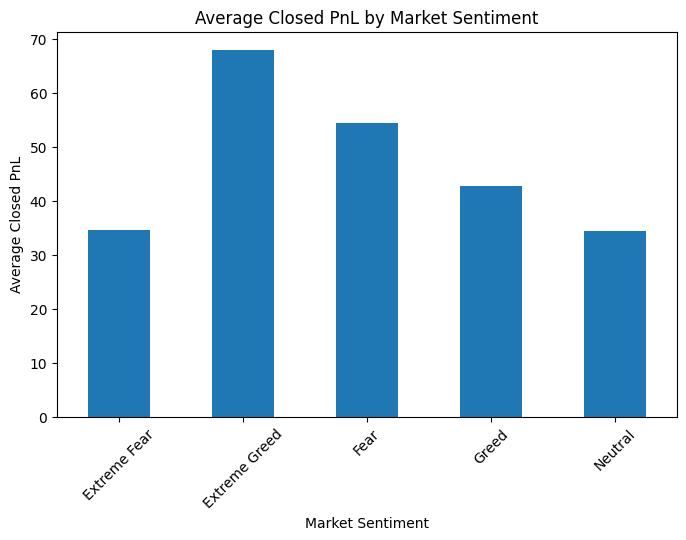

In [13]:
# Plot average pnl by sentiment

pnl_summary["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)

plt.show()

In [ ]:
df["is_profit"] = df["Closed PnL"] > 0

In [15]:
# Win rate %

win_rate = df.groupby(
    "classification"
)["is_profit"].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


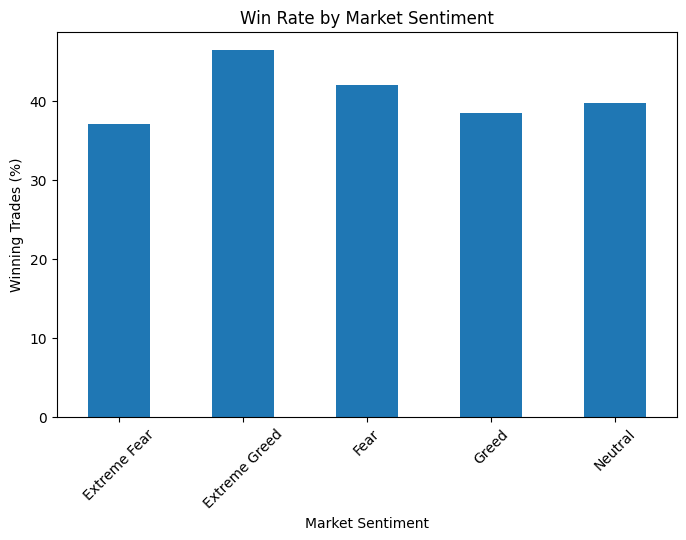

In [16]:
win_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Winning Trades (%)")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)

plt.show()

In [17]:
trade_count = df.groupby(
    "classification"
).size()

print(trade_count)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


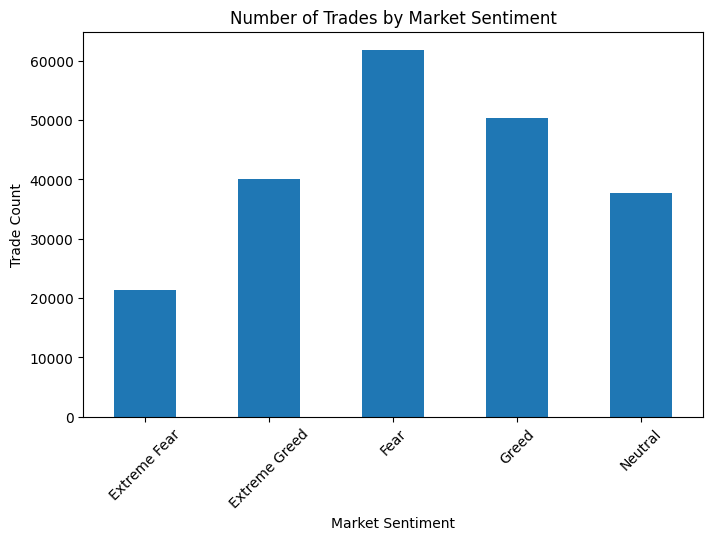

In [18]:
trade_count.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Trades by Market Sentiment")
plt.ylabel("Trade Count")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)

plt.show()

In [19]:
side_summary = df.groupby(
    ["classification", "Side"]
)["Closed PnL"].mean()

print(side_summary)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


In [20]:
side_plot = df.pivot_table(
    values="Closed PnL",
    index="classification",
    columns="Side",
    aggfunc="mean"
)

print(side_plot)

Side                  BUY        SELL
classification                       
Extreme Fear    34.114627   34.980106
Extreme Greed   10.498927  114.584643
Fear            63.927104   45.049641
Greed           25.002302   59.691091
Neutral         29.227429   39.456408


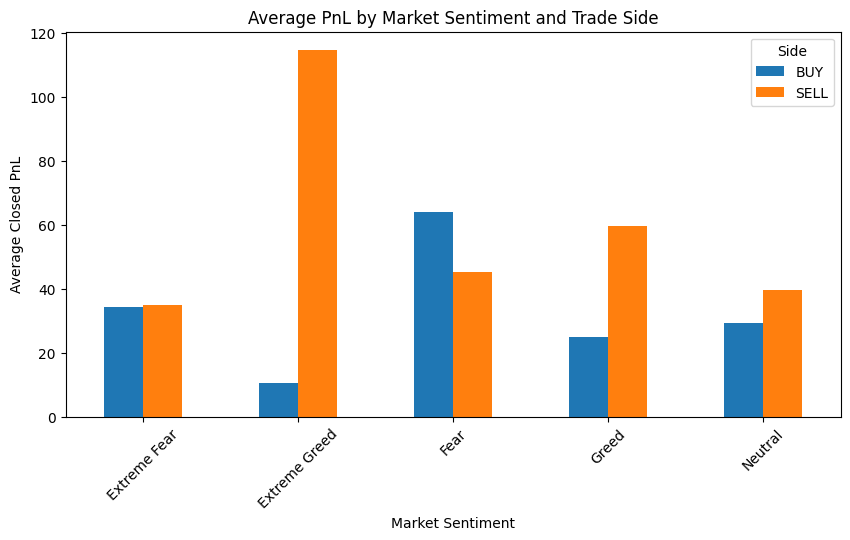

In [21]:
side_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average PnL by Market Sentiment and Trade Side")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)

plt.show()

In [22]:
top_traders = df.groupby("Account").agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    trades=("Account", "count")
)

In [23]:
top_10 = top_traders.sort_values(
    "total_pnl",
    ascending=False
).head(10)

print(top_10)

                                               total_pnl     avg_pnl  trades
Account                                                                     
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  145.481748   14733
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  419.127768    3818
0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05   44.364091   21192
0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05   68.684419   12236
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05   20.806305   40184
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05  155.589314    4356
0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  270.034947    1590
0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05  336.735548    1237
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  4.030115e+05  281.826227    1430
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05   38.319560    9893


In [24]:
# Aggregate trader behavior per day

daily_features = df.groupby("date").agg(
    avg_pnl=("Closed PnL", "mean"),
    total_pnl=("Closed PnL", "sum"),
    trade_count=("Account", "count"),
    avg_fee=("Fee", "mean"),
    buy_count=("Side", lambda x: (x == "BUY").sum()),
    sell_count=("Side", lambda x: (x == "SELL").sum()),
    classification=("classification", "first")
).reset_index()
daily_features = df.groupby("date").agg(
    avg_pnl=("Closed PnL", "mean"),
    total_pnl=("Closed PnL", "sum"),
    trade_count=("Account", "count"),
    avg_fee=("Fee", "mean"),
    buy_count=("Side", lambda x: (x == "BUY").sum()),
    sell_count=("Side", lambda x: (x == "SELL").sum()),
    classification=("classification", "first")
).reset_index()

In [25]:
daily_features.head()

,date,avg_pnl,total_pnl,trade_count,avg_fee,buy_count,sell_count,classification
0,2023-05-01,0.000000,0.000000,3,0.000000,3,0,Greed
1,2023-12-05,0.000000,0.000000,9,1.389051,7,2,Extreme Greed
2,2023-12-14,-18.675885,-205.434737,11,2.572803,5,6,Greed
3,2023-12-15,-12.316017,-24.632034,2,1.326245,2,0,Greed
4,2023-12-16,0.000000,0.000000,3,1.279063,3,0,Greed


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features
X = daily_features[
    [
        "avg_pnl",
        "total_pnl",
        "trade_count",
        "avg_fee",
        "buy_count",
        "sell_count"
    ]
]

# Target
y = daily_features["classification"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train
model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Full report
print(classification_report(y_test, y_pred))

Accuracy: 0.3958333333333333
               precision    recall  f1-score   support

 Extreme Fear       0.00      0.00      0.00         3
Extreme Greed       0.48      0.50      0.49        28
         Fear       0.37      0.39      0.38        18
        Greed       0.36      0.48      0.41        31
      Neutral       0.50      0.12      0.20        16

     accuracy                           0.40        96
    macro avg       0.34      0.30      0.30        96
 weighted avg       0.41      0.40      0.38        96



In [27]:
# Remove rows with missing values

daily_features = daily_features.dropna()